In [ ]:
import sys
sys.path.append('../')

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as m_colors
from matplotlib.patches import ConnectionPatch
import pandas as pd
from tqdm.auto import tqdm
import seaborn as sns

from src.util import (degree_of_convexity_cielab,
                      compression,
                      safelog,
                      complexity,
                      informativity
                      )


sns.set(context='paper', 
        style='ticks', 
        font_scale=1.1,
        font='serif',
        )

In [2]:
def cost(grid, p_m, cielab_dict):
    '''
    Cost function from Carr et al. (2020) for the informativeness of a grid.
    '''
    # get all unique values in the grid
    C = np.unique(grid)
    # get list of all coordinates of each cell in the grid
    M = [(i, j) for i in range(grid.shape[0]) 
                       for j in range(grid.shape[1])]
    # p_m equals to 1 divided by the number of cells in the grid
    if p_m is None:
        p_m = np.array([1 / len(M)] * len(M))
        # p_m = p_m.reshape((8, 40))
        p_m = p_m.reshape(grid.shape)   

    cost_ = 0

    for c in C:
        coords = np.argwhere(grid == c)
        for m in M:
            # coordiantes should be mapped using cielab_dict
            coords_cielab = np.array([cielab_dict[tuple(k)] for k in coords.tolist()])
            distance = np.linalg.norm(cielab_dict[m] - coords_cielab) ** 2
            cost_ += np.exp( - (p_m[m] * distance))
    return cost_


def informativeness(grid, p_m, cielab_dict):
    '''
    Compute the informativeness of a grid using the cost function from Carr et al. (2020).
    '''
    return -safelog(cost(grid, p_m, cielab_dict))


In [3]:
def plot_color_grid(grid, rgb_dict, prior_m_matrix):
    """
    NB: old version for cropped color maps
    """
    
    # Create an empty dictionary to store the RGB values for each unique category in the grid
    color_map = dict()

    # Loop through each unique category in the grid
    for color_c in np.unique(grid):
        # Get the coordinates of all cells belonging to the current category
        coordinates = np.argwhere(grid == color_c)
        
        # Extract probabilities for each coordinate from prior_m_matrix and normalize them
        probs = [prior_m_matrix[coord[0], coord[1]] for coord in coordinates]
        probs = np.array(probs) / sum(probs)

        # Find the coordinate with the highest probability
        max_prob_coord = coordinates[np.argmax(probs)]
        
        # Map the category to its corresponding RGB value
        color_map[color_c] = rgb_dict[max_prob_coord[0] + 1, max_prob_coord[1] + 1]

    # Create an empty image with the same shape as the grid but with an additional dimension for RGB channels
    image = np.zeros((grid.shape[0], grid.shape[1], 3))

    # Assign colors to each cell in the image based on the grid values and color_map
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            image[i, j] = color_map[grid[i, j]]

    return image

In [4]:
# unpockle IB_color_naming.pkl from data
with open('../data/IB_color_naming.pkl', 'rb') as f:
    IB_color_naming = pickle.load(f)

# unpickle chip dict
with open('../data/chip_dict.pkl', 'rb') as f:
    chip_dict = pickle.load(f)

# unpickle sielab_dict
with open('../data/cielab_dict.pkl', 'rb') as f:
    cielab_dict = pickle.load(f)   

# unpickle rgb_dict
with open('../data/rgb_dict.pkl', 'rb') as f:
    rgb_dict = pickle.load(f)

# unpickle languages
with open('../data/lg_color.pkl', 'rb') as f:
    lg_color = pickle.load(f)

# unpickle lang_info
with open('../data/lang_info.pkl', 'rb') as f:
    lang_info = pickle.load(f)


### IB machinery

In [5]:
# unpickle ib curve
with open('../data/ib_curve.pkl', 'rb') as f:
    IB_c = pickle.load(f)

In [6]:
import string

# Constants
ROWS = [string.ascii_uppercase[i] for i in range(10)]  # ['A', 'B', ..., 'J']

# Load WCS data
WCS_CNUM_FILE = '../data/raw/chip.txt'  # Replace with actual path to chip.txt
WCS_CNUMS = pd.read_csv(WCS_CNUM_FILE, delimiter='\t', header=None).values

# Create mapping between chip numbers and coordinates
CNUMS_WCS_COR = dict(zip(
    WCS_CNUMS[:, 0],  # Chip number
    [(ROWS.index(WCS_CNUMS[cnum - 1, 1]), WCS_CNUMS[cnum - 1, 2]) for cnum in WCS_CNUMS[:, 0]]  # (row, column)
))

# Build DataFrame for fast lookups
DF = pd.DataFrame({'cnum': np.arange(1, 331)})
DF['x'] = DF['cnum'].apply(lambda x: CNUMS_WCS_COR[x][0])
DF['y'] = DF['cnum'].apply(lambda x: CNUMS_WCS_COR[x][1])
DF.set_index(['x', 'y'], inplace=True)

def ind2cnum(x, y):
    """
    Convert location in the WCS palette to chip number.
    Example: ind2cnum(2, 22) returns 100.
    """
    return DF.loc[x, y]['cnum']

In [7]:
with open('../data/pM.pkl', 'rb') as f:
    p_m = pickle.load(f)

cielab_coords = pd.read_csv('../data/raw/cnum-vhcm-lab-new.txt', sep='\t')
coords_correct = cielab_coords.sort_values(by='#cnum')[['L*', 'a*', 'b*']].values.tolist()

pU_m_d = np.zeros((330, 330))
sigma = 8

for i_, i in enumerate(coords_correct):
    for j_, j in enumerate(coords_correct):
        d = np.exp( - (1 / (2 * sigma ** 2)) * np.linalg.norm(np.array(i) - np.array(j)) ** 2)
        pU_m_d[i_, j_] = d

pU_m_d /= pU_m_d.sum(axis=1)[:,np.newaxis]

In [8]:
def clean_partition(partition):
    """
    Normalizes the values in the partition to sequential integers (0 to voc_size - 1),
    ignoring NaN values.
    """
    unique_vals = np.unique(partition[~np.isnan(partition)])  # Ignore NaN for unique values
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    # Vectorize the mapping, explicitly checking for NaN
    return np.vectorize(lambda x: mapping.get(x, -1))(partition)

def binary(partition, offset=1):
    """
    Converts a partition matrix into a one-hot encoded matrix.
    Handles special cases for outlier chips.
    """
    # Determine vocabulary size (excluding NaN)
    voc_size = len(np.unique(partition[~np.isnan(partition)])) + 1  

    # Initialize the encoder matrix
    encoder = np.zeros((330, voc_size))

    for i in range(partition.shape[0]):
        for j in range(partition.shape[1]):
            val = partition[i, j]
            if np.isnan(val) or val < 0:
                continue  # Skip invalid or missing entries
            try:
                chip_index = int(ind2cnum(i + offset, j + offset))
                word_index = int(val)
                encoder[chip_index - 1, word_index] = 1.0
            except KeyError:
                # Skip coordinates not found in DF
                continue

    return encoder

In [9]:
informativity(binary(lg_color[1][1:-1, 1:], offset=2), pU_m_d, p_m)

1.591527827278529

In [10]:
prior_m = IB_color_naming['pM']

# match index of prior_m to chip_dict coordinates 
# and build a new dict (coordinate: probability)
prior_m_ = []
for i, p in enumerate(prior_m):
    prior_m_.append((chip_dict[i+1], p))

# remove entries with first coordinate == 1
prior_m_ = [x for x in prior_m_ if x[0][1] != 0]

# use coordinate from prior_m_ to build a matrix with probabilities
prior_m_matrix = np.zeros((8, 40))
for c, p in prior_m_:
    prior_m_matrix[c[0]-1, c[1]-1] = p

In [11]:
# only choose coordinates in the range (0, 0), (8, 40)
cielab_dict_ = {k: v for k, v in cielab_dict.items() if k[0] in range(0, 9) and k[1] in range(0, 41)}

# reverse keys and values in cielab_dict_
cielab_dict_r = {v: k for k, v in cielab_dict_.items()}

# convert cielab_dict_ to a list of tuples ordered from (0, 0) to (8, 40)
cielab_list = [cielab_dict_[k] for k in sorted(cielab_dict_.keys())]

# open data/optimal_artificial_languages.pkl
with open('../data/optimal_artificial_languages.pkl', 'rb') as f:
    optimal_languages = pickle.load(f)

In [12]:
prior_m_matrix.shape

(8, 40)

In [40]:
shifts = np.arange(-20, 21)
data = []

# Iterate over all shifts and languages
for s in tqdm(shifts):
    for lg in lg_color:
        shifted = np.roll(lg_color[lg][1:-1, 1:], shift=s, axis=1)
        expanded = np.expand_dims(shifted, axis=0)

        # to-do: need to get IB-friendly encodings for each language, given that we removed the first column
        
        
        convexity = degree_of_convexity_cielab(expanded, cielab_dict_, cielab_list, cut=True)[0]
        compression_ = compression(expanded)
        informativeness_ = informativeness(shifted, prior_m_matrix, cielab_dict_)
        distance_to_optimal = np.min([np.linalg.norm(np.array([compression_, informativeness_]) - np.array([simp, info])) 
                                      for simp, info in optimal_languages])
        
        # IB measures
        informativity_ = informativity(binary(shifted, offset=1), pU_m_d, p_m)
        complexity_ = complexity(binary(shifted, offset=1), p_m)
        # Distance to IB curve (horizontal distance, parallel to x-axis)
        # Find the IB curve point with minimal vertical distance to current (complexity_, informativity_)
        idx = np.argmin(np.abs(IB_c[1] - informativity_))
        distance_IB = np.abs(complexity_ - IB_c[0][idx])

        # Store data for plotting
        data.append({"shift": s, "convexity": convexity, "language": lg, 'compression': compression_, 
                     'informativeness': informativeness_, 'distance': distance_to_optimal, 
                     'informativity': informativity_, 'complexity': complexity_,
                     'distance_IB': distance_IB})

# Convert to DataFrame
df_horizontal = pd.DataFrame(data)

  0%|          | 0/41 [00:00<?, ?it/s]

In [41]:
df_horizontal['convexity_n'] = (df_horizontal['convexity'] - df_horizontal['convexity'].min()) / (df_horizontal['convexity'].max() - df_horizontal['convexity'].min())
df_horizontal['convexity_diff'] = df_horizontal.groupby('language')['convexity_n'].transform(lambda x: x - x.iloc[20])
df_horizontal['convexity_diff_pos'] = df_horizontal.groupby('language')['convexity_n'].transform(lambda x: abs(x - x.iloc[20]))
# df_horizontal['convexity_diff'] = df_horizontal['convexity_diff']/df_horizontal['convexity'].max()

In [42]:
# normalize distance first
df_horizontal['distance_n'] = 1 - (df_horizontal['distance'] - df_horizontal['distance'].min()) / (df_horizontal['distance'].max() - df_horizontal['distance'].min())
df_horizontal['distance_diff'] = df_horizontal.groupby('language')['distance_n'].transform(lambda x: x - x.iloc[20])
# df_horizontal['distance_diff'] = df_horizontal['distance_diff']/df_horizontal['distance'].max()

In [43]:
# normalize compression first
df_horizontal['compression_n'] = 1 - (df_horizontal['compression'] - df_horizontal['compression'].min()) / (df_horizontal['compression'].max() - df_horizontal['compression'].min())
df_horizontal['compression_diff'] = df_horizontal.groupby('language')['compression_n'].transform(lambda x: abs(x - x.iloc[20]))
# df_horizontal['compression_diff'] = df_horizontal['compression_diff']/df_horizontal['compression'].min()

In [44]:
# normalize informativeness first
df_horizontal['informativeness_n'] = 1 - (df_horizontal['informativeness'] - df_horizontal['informativeness'].min()) / (df_horizontal['informativeness'].max() - df_horizontal['informativeness'].min())
df_horizontal['informativeness_diff'] = df_horizontal.groupby('language')['informativeness_n'].transform(lambda x: abs(x - x.iloc[20]))

In [45]:
df_horizontal['informativity_n'] = (df_horizontal['informativity'] - df_horizontal['informativity'].min()) / (df_horizontal['informativity'].max() - df_horizontal['informativity'].min())
df_horizontal['informativity_diff'] = df_horizontal.groupby('language')['informativity_n'].transform(lambda x: x - x.iloc[20])

In [46]:
df_horizontal['complexity_n'] = (df_horizontal['complexity'] - df_horizontal['complexity'].min()) / (df_horizontal['complexity'].max() - df_horizontal['complexity'].min())
df_horizontal['complexity_diff'] = df_horizontal.groupby('language')['complexity_n'].transform(lambda x: x - x.iloc[20])

In [47]:
# same for distance_IB
df_horizontal['distance_IB_n'] = 1 - (df_horizontal['distance_IB'] - df_horizontal['distance_IB'].min()) / (df_horizontal['distance_IB'].max() - df_horizontal['distance_IB'].min())
df_horizontal['distance_IB_diff'] = df_horizontal.groupby('language')['distance_IB_n'].transform(lambda x: x - x.iloc[20])

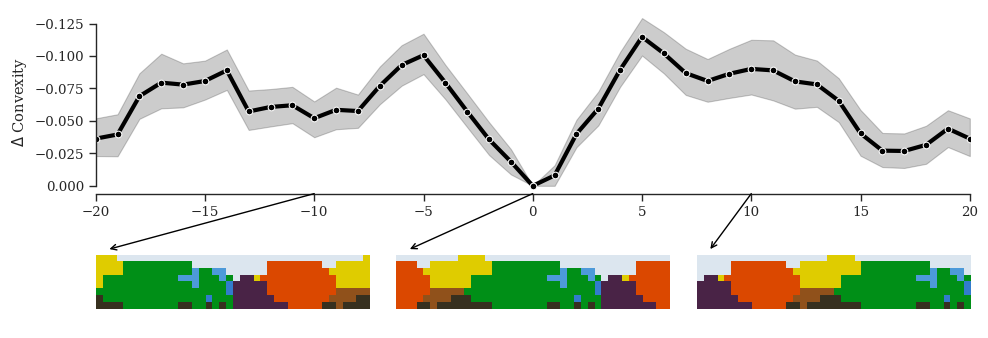

In [63]:
fig, axes = plt.subplots(nrows=2, 
                         figsize=(10, 3.5), 
                         gridspec_kw={'height_ratios': [2, 1]})

# First plot (Line plot)
sns.lineplot(
    data=df_horizontal, 
    x="shift", 
    y="convexity_diff", 
    linewidth=3,
    color='black',
    marker='o',
    ax=axes[0],
    errorbar=('ci', 95),
)
axes[0].set_xlabel("")
axes[0].set_ylabel(r"$\Delta$ Convexity")
axes[0].set_xlim(-20, 20)
# axes[0].set_ylim(None, 0)
axes[0].invert_yaxis()
sns.despine(ax=axes[0],
            # offset=1,
            trim=True,
            )

# Second row: 3 horizontally arranged images
img = plot_color_grid(lg_color[4][1:-1, 1:], rgb_dict, prior_m_matrix)

# Clean up the parent axis of the bottom row
axes[1].axis('off')  # Turn off the parent axis entirely
axes[1].grid(False)  # Ensure no grid persists

# Create subplots inside axes[1]
subgrid = axes[1].get_subplotspec().subgridspec(1, 3)
for idx, shift in enumerate([-10, 0, 10]):
    ax_img = fig.add_subplot(subgrid[0, idx])
    ax_img.imshow(np.roll(img, shift=shift, axis=1), interpolation='none')
    # ax_img.set_title(f'{shift}', fontsize=10, loc='left')
    ax_img.axis('off')  # Remove all borders and ticks
    ax_img.grid(False)  # Explicitly disable grid

    # rasterize the image to avoid aliasing artifacts
    ax_img.set_rasterization_zorder(1)

    # Add connecting lines
    con = ConnectionPatch(
        xyA=(shift, 0.006),  # Point in the top plot (x=shift, y=0)
        xyB=(0.05, 1.1),    # Point in the bottom plot (center top of the image)
        coordsA="data",  # Use data coordinates for the top plot
        coordsB="axes fraction",  # Use axes fraction for the bottom plot
        axesA=axes[0],   # Top plot
        axesB=ax_img,    # Bottom subplot
        color="black",   # Line color # Dashed line
        linewidth=1, 
        arrowstyle='->'
    )
    fig.add_artist(con)

# Tighten layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.1)  # Minimize space between images
plt.subplots_adjust(hspace=0.3)  # Minimize space between subplots
plt.savefig('../figures/Figure_6.pdf', dpi=300, bbox_inches='tight')
plt.show()

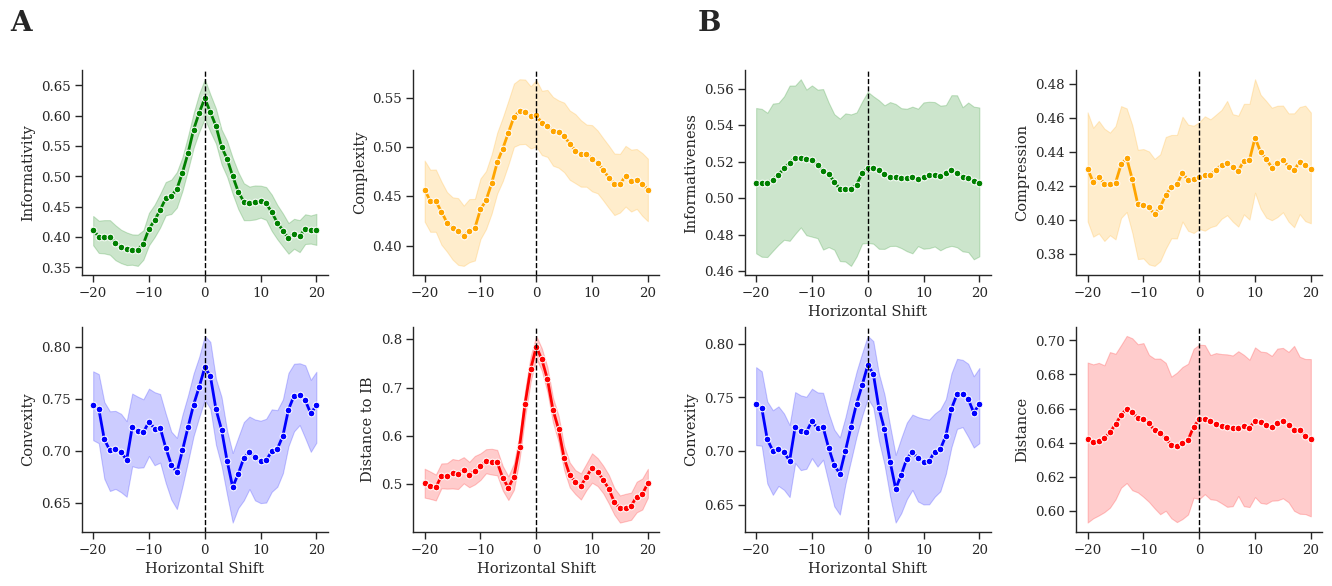

In [ ]:
# ------------------------------------------------------------------
# Create a wide figure with two 2×2 panels side-by-side
# ------------------------------------------------------------------
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 4, wspace=0.35, hspace=0.25)

# ------------------------------------------------------------------
# Panel A – original layout (left side)
# ------------------------------------------------------------------
axA11 = fig.add_subplot(gs[0, 0])  # Informativity
axA12 = fig.add_subplot(gs[0, 1])  # Complexity
axA21 = fig.add_subplot(gs[1, 0])  # Convexity
axA22 = fig.add_subplot(gs[1, 1])  # Distance to IB

# Informativity (A)
sns.lineplot(data=df_horizontal, x="shift", y="informativity_n",
             linewidth=2, color='green', marker='o',
             errorbar=('ci', 95), ax=axA11)
axA11.set_xlabel("")
axA11.set_ylabel("Informativity")
axA11.axvline(0, color='black', linestyle='--', linewidth=1)

# Complexity (A)
sns.lineplot(data=df_horizontal, x="shift", y="complexity_n",
             linewidth=2, color='orange', marker='o',
             errorbar=('ci', 95), ax=axA12)
axA12.set_xlabel("")
axA12.set_ylabel("Complexity")
axA12.axvline(0, color='black', linestyle='--', linewidth=1)

# Convexity (A)
sns.lineplot(data=df_horizontal, x="shift", y="convexity_n",
             linewidth=2, color='blue', marker='o',
             errorbar=('ci', 95), ax=axA21)
axA21.set_xlabel("Horizontal Shift")
axA21.set_ylabel("Convexity")
axA21.axvline(0, color='black', linestyle='--', linewidth=1)

# Distance to IB (A)
sns.lineplot(data=df_horizontal, x="shift", y="distance_IB_n",
             linewidth=2, color='red', marker='o',
             errorbar=('ci', 95), ax=axA22)
axA22.set_xlabel("Horizontal Shift")
axA22.set_ylabel("Distance to IB")
axA22.axvline(0, color='black', linestyle='--', linewidth=1)

# ------------------------------------------------------------------
# Panel B – Convexity in top-right
# ------------------------------------------------------------------
# Grid for B: columns 2 and 3
#   [ Informativeness | Convexity ]   <- top row
#   [ Compression     | Distance   ]   <- bottom row

axB11 = fig.add_subplot(gs[0, 2])  # Informativeness – top-left
axB21 = fig.add_subplot(gs[0, 3])  # Convexity – top-right
axB12 = fig.add_subplot(gs[1, 2])  # Compression – bottom-left
axB22 = fig.add_subplot(gs[1, 3])  # Distance – bottom-right

# Informativeness (B)
sns.lineplot(data=df_horizontal, x="shift", y="informativeness_n",
             linewidth=2, color='green', marker='o',
             errorbar=('ci', 95), ax=axB11)
axB11.set_xlabel("")
axB11.set_ylabel("Informativeness")
axB11.axvline(0, color='black', linestyle='--', linewidth=1)

# Convexity (B)
sns.lineplot(data=df_horizontal, x="shift", y="convexity_n",
             linewidth=2, color='blue', marker='o',
             errorbar=('ci', 95), ax=axB12)
axB12.set_xlabel("Horizontal Shift")
axB12.set_ylabel("Convexity")
axB12.axvline(0, color='black', linestyle='--', linewidth=1)

# Compression (B)
sns.lineplot(data=df_horizontal, x="shift", y="compression_n",
             linewidth=2, color='orange', marker='o',
             errorbar=('ci', 95), ax=axB21)
axB21.set_xlabel("")
axB21.set_ylabel("Compression")
axB21.axvline(0, color='black', linestyle='--', linewidth=1)

# Distance (B)
sns.lineplot(data=df_horizontal, x="shift", y="distance_n",
             linewidth=2, color='red', marker='o',
             errorbar=('ci', 95), ax=axB22)
axB22.set_xlabel("Horizontal Shift")
axB22.set_ylabel("Distance")
axB22.axvline(0, color='black', linestyle='--', linewidth=1)

# ------------------------------------------------------------------
# Final styling
# ------------------------------------------------------------------
sns.despine()

# Panel labels A and B
fig.text(0.08, 0.98, "A", fontsize=20, fontweight="bold", va="top")
fig.text(0.51, 0.98, "B", fontsize=20, fontweight="bold", va="top")

plt.savefig('../figures/Figure_2s.pdf', dpi=300, bbox_inches='tight')
plt.show()

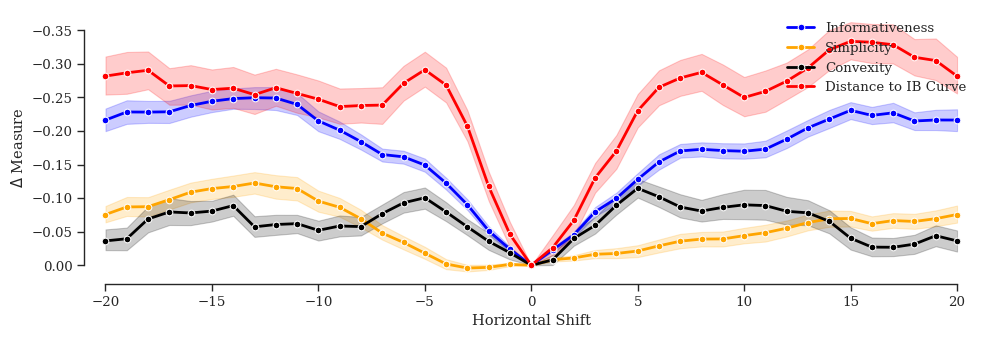

In [62]:
fig, ax = plt.subplots(figsize=(10, 3.5))

sns.lineplot(
    data=df_horizontal, 
    x="shift", 
    y="informativity_diff", 
    linewidth=2,
    color='blue',
    marker='o',
    ax=ax,
    label='Informativeness',
    errorbar=('ci', 95),
)
sns.lineplot(
    data=df_horizontal, 
    x="shift", 
    y="complexity_diff", 
    linewidth=2,
    color='orange',
    marker='o',
    ax=ax,
    label='Simplicity',
    errorbar=('ci', 95),
)
sns.lineplot(
    data=df_horizontal, 
    x="shift", 
    y="convexity_diff", 
    linewidth=2,
    color='black',
    marker='o',
    ax=ax,
    label='Convexity',
    errorbar=('ci', 95),
)
sns.lineplot(
    data=df_horizontal, 
    x="shift", 
    y="distance_IB_diff", 
    linewidth=2,
    color='red',
    marker='o',
    ax=ax,
    label='Distance to IB Curve',
    errorbar=('ci', 95),
)
ax.set_xlabel("Horizontal Shift")
ax.set_ylabel(r"$\Delta$ Measure")
ax.set_xlim(-21, 21)
ax.legend(frameon=False, loc='upper right')
# flip the y axis
ax.invert_yaxis()
sns.despine(ax=ax, 
            # offset=1, 
            trim=True)
plt.tight_layout()
plt.savefig('../figures/Figure_7.pdf', dpi=300, bbox_inches='tight')
plt.show()
